# Knowledge Graphs for JIT-SDP — Methodology Tour

This notebook builds **five different styles of Knowledge Graph** from the same Apache JIT commit data, each following a well-known methodology from the KG literature. The aim is **breadth, not depth** — each section is a minimal, runnable example so you can compare syntaxes and pick the one that best fits a downstream model.

| # | Methodology | Where it comes from | What it captures |
|---|---|---|---|
| 1 | RDF Triples | Semantic Web / W3C | Subject-Predicate-Object facts |
| 2 | Property Graph (NetworkX) | Neo4j / igraph tradition | Nodes & edges with arbitrary attributes |
| 3 | Heterogeneous Multi-Relational Graph | Modern GNN papers (R-GCN, HAN) | Multiple node & edge **types** |
| 4 | Temporal / Dynamic KG | Streaming-graph research | Graph snapshots evolving over time |
| 5 | Adjacency-Matrix View | Spectral / matrix-factorization KG methods | Numeric encoding suitable for linear algebra |

All five use the same underlying entities derived from the dataset columns:
`commit_id, project, buggy, fix, year, author_date, la, ld, nf, nd, ns, ent, ndev, age, nuc, aexp, arexp, asexp`.


## Setup — load a small sample of commits

We pull a few hundred commits across a handful of projects to keep visualizations readable. The same construction code scales to the full dataset by removing the `head(...)` call.

In [30]:
import sys, os
from pathlib import Path

# Make the project root importable from inside the notebook
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'kg_commit').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict, Counter

DATA_PATH = PROJECT_ROOT / 'data' / 'apachejit' / 'apachejit_train.csv'
df_full = pd.read_csv(DATA_PATH)

# Keep 5 projects with the most commits, then sample 60 commits from each
top_projects = df_full['project'].value_counts().head(5).index.tolist()
df = (df_full[df_full['project'].isin(top_projects)]
      .groupby('project', group_keys=False)
      .apply(lambda g: g.sort_values('author_date').head(60))
      .reset_index(drop=True))

print(f'Total commits in sample : {len(df)}')
print(f'Projects                : {top_projects}')
print(f'Bug rate in sample      : {df["buggy"].mean():.3f}')
df.head(3)

Total commits in sample : 300
Projects                : ['apache/camel', 'apache/cassandra', 'apache/hbase', 'apache/ignite', 'apache/hive']
Bug rate in sample      : 0.473


C:\Users\sinab\AppData\Local\Temp\ipykernel_7732\2277841263.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('author_date').head(60))


,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
0,77b260b65ba821b3443d922320cc3d9b708c8d83,apache/camel,False,False,2007,1174301697,2295,0,42,8,1,5.074919,0.000000,0.0,0.000000,0,0.0,0.0
1,a4701ac4bf5b50810914796e284b0e3f78a240bc,apache/camel,False,False,2007,1174306940,147,46,10,4,1,2.875453,0.000000,0.0,0.000000,2,2.0,0.0
2,0a0bad2c4a35be88f7732def261a03737fab662e,apache/camel,True,False,2007,1174310317,295,114,13,2,1,3.074528,0.076923,0.0,0.461538,3,3.0,1.0


---
## 1. RDF Triples — the Semantic-Web foundation

The oldest and most general KG representation is a set of `(subject, predicate, object)` triples — the basis of RDF, SPARQL, and the entire W3C linked-data stack. Every fact is its own self-describing row, which makes the graph easy to serialize, query, or merge with other data.

For JIT-SDP a single commit naturally produces multiple triples:

```
(commit_abc123, :inProject,  apache/kafka)
(commit_abc123, :authoredIn, 2014)
(commit_abc123, :hasLabel,   :Buggy)
(commit_abc123, :linesAdded, 47)
```

We'll store these as plain Python tuples — no `rdflib` dependency needed for the demo.

In [31]:
triples = []
for _, row in df.iterrows():
    c = f"commit:{row['commit_id'][:7]}"
    triples.append((c, ':inProject',  f"proj:{row['project']}"))
    triples.append((c, ':authoredIn', f"year:{int(row['year'])}"))
    triples.append((c, ':hasLabel',   ':Buggy' if row['buggy'] else ':Clean'))
    triples.append((c, ':isFix',      ':Yes' if row['fix'] else ':No'))

print(f'Total triples : {len(triples)}')
print('\nFirst 8 triples:')
for t in triples[:8]:
    print(f'  {t[0]:<22} {t[1]:<14} {t[2]}')

# Count predicate frequencies
pred_counts = Counter(p for _, p, _ in triples)
print('\nPredicate frequency:', dict(pred_counts))

Total triples : 1200

First 8 triples:
  commit:77b260b         :inProject     proj:apache/camel
  commit:77b260b         :authoredIn    year:2007
  commit:77b260b         :hasLabel      :Clean
  commit:77b260b         :isFix         :No
  commit:a4701ac         :inProject     proj:apache/camel
  commit:a4701ac         :authoredIn    year:2007
  commit:a4701ac         :hasLabel      :Clean
  commit:a4701ac         :isFix         :No

Predicate frequency: {':inProject': 300, ':authoredIn': 300, ':hasLabel': 300, ':isFix': 300}


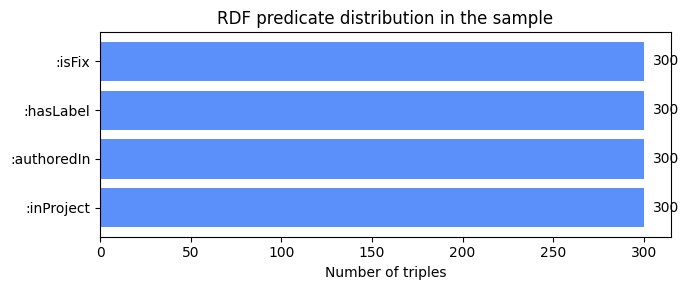

In [32]:
# Visualize predicate distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(pred_counts.keys()), list(pred_counts.values()), color='#5B8FF9')
ax.set_xlabel('Number of triples')
ax.set_title('RDF predicate distribution in the sample')
for i, v in enumerate(pred_counts.values()):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout(); plt.show()

### 1b. SPARQL-style queries on RDF triples

Without a triplestore, our Python list of triples already supports pattern-match queries — the equivalent of a SPARQL `WHERE { ?s ?p ?o }` clause. Three practical JIT-SDP questions:


In [33]:
# SPARQL-style pattern-match queries — no triplestore required

def query(triples, subject=None, predicate=None, obj=None):
    return [t for t in triples
            if (subject   is None or t[0] == subject)
            and (predicate is None or t[1] == predicate)
            and (obj       is None or t[2] == obj)]

# Q1: All buggy commits in the first project
proj0         = f"proj:{top_projects[0]}"
in_proj0      = {t[0] for t in query(triples, predicate=':inProject', obj=proj0)}
all_buggy     = {t[0] for t in query(triples, predicate=':hasLabel',  obj=':Buggy')}
q1 = in_proj0 & all_buggy
print(f"Q1  Buggy commits in {top_projects[0]}: {len(q1)}")

# Q2: Commits authored after 2015
q2 = {t[0] for t in triples
      if t[1] == ':authoredIn' and int(t[2].split(':')[1]) > 2015}
print(f"Q2  Commits authored after 2015        : {len(q2)}")

# Q3: Fix commits that are also labelled buggy (risky — introduce a bug while fixing)
fix_commits = {t[0] for t in query(triples, predicate=':isFix', obj=':Yes')}
q3 = fix_commits & all_buggy
print(f"Q3  Buggy fix-commits (risky fixes)    : {len(q3)}")
print("    Sample:", list(q3)[:4])


Q1  Buggy commits in apache/camel: 26
Q2  Commits authored after 2015        : 0
Q3  Buggy fix-commits (risky fixes)    : 0
    Sample: []


In [34]:
# SPARQL-style queries using list comprehensions — no triplestore needed

def query(triples, subject=None, predicate=None, obj=None):
    return [t for t in triples
            if (subject   is None or t[0] == subject)
            and (predicate is None or t[1] == predicate)
            and (obj       is None or t[2] == obj)]

# Q1: Buggy commits in the first project
proj0 = f"proj:{top_projects[0]}"
in_proj0   = {t[0] for t in query(triples, predicate=':inProject', obj=proj0)}
buggy_all  = {t[0] for t in query(triples, predicate=':hasLabel',  obj=':Buggy')}
q1 = in_proj0 & buggy_all
print(f"Q1  Buggy commits in {top_projects[0]}: {len(q1)}")

# Q2: Commits authored after 2015
q2 = {t[0] for t in triples if t[1] == ':authoredIn' and int(t[2].split(':')[1]) > 2015}
print(f"Q2  Commits authored after 2015        : {len(q2)}")

# Q3: Fix commits that are also labelled buggy (re-introduce bugs while fixing)
fix_commits = {t[0] for t in query(triples, predicate=':isFix',    obj=':Yes')}
q3 = fix_commits & buggy_all
print(f"Q3  Buggy fix-commits (risky fixes)    : {len(q3)}")
if q3:
    print("    Sample:", list(q3)[:4])


Q1  Buggy commits in apache/camel: 26
Q2  Commits authored after 2015        : 0
Q3  Buggy fix-commits (risky fixes)    : 0


**Why RDF for JIT-SDP?** Every commit fact is independent and addressable. You can dump the triples to Turtle/N-Triples, run SPARQL over them, or load them into any RDF triplestore. The downside: pure triples carry no notion of *order*, which matters for streaming defect prediction.

---
## 2. Property Graph (NetworkX) — the practical Python approach

Property graphs (the Neo4j / Cypher model) generalize RDF: nodes and edges can each carry an arbitrary key-value dictionary. NetworkX is the de-facto Python implementation. This is the format **most ML pipelines actually use** because attributes can be read directly into feature vectors.

We build a directed graph where:
- **Commit nodes** carry their numeric features (`la`, `ld`, `ent`, ...).
- **Project nodes** are added once.
- Edges `commit --in--> project` connect them.

In [35]:
G = nx.DiGraph()
for _, row in df.iterrows():
    cid = row['commit_id'][:7]
    G.add_node(cid, kind='commit', buggy=bool(row['buggy']),
               la=float(row['la']), ld=float(row['ld']), ent=float(row['ent']))
    G.add_node(row['project'], kind='project')
    G.add_edge(cid, row['project'], rel='in_project')

print(f'Nodes : {G.number_of_nodes()}  ({sum(1 for _,d in G.nodes(data=True) if d["kind"]=="commit")} commits + {len(top_projects)} projects)')
print(f'Edges : {G.number_of_edges()}')

# Per-project bug rates from node attributes
for proj in top_projects:
    commits_in_proj = [n for n in G.predecessors(proj)]
    bug_rate = np.mean([G.nodes[c]['buggy'] for c in commits_in_proj])
    print(f'  {proj:<25} bug rate = {bug_rate:.3f}')

Nodes : 305  (300 commits + 5 projects)
Edges : 300
  apache/camel              bug rate = 0.433
  apache/cassandra          bug rate = 0.267
  apache/hbase              bug rate = 0.617
  apache/ignite             bug rate = 0.183
  apache/hive               bug rate = 0.867


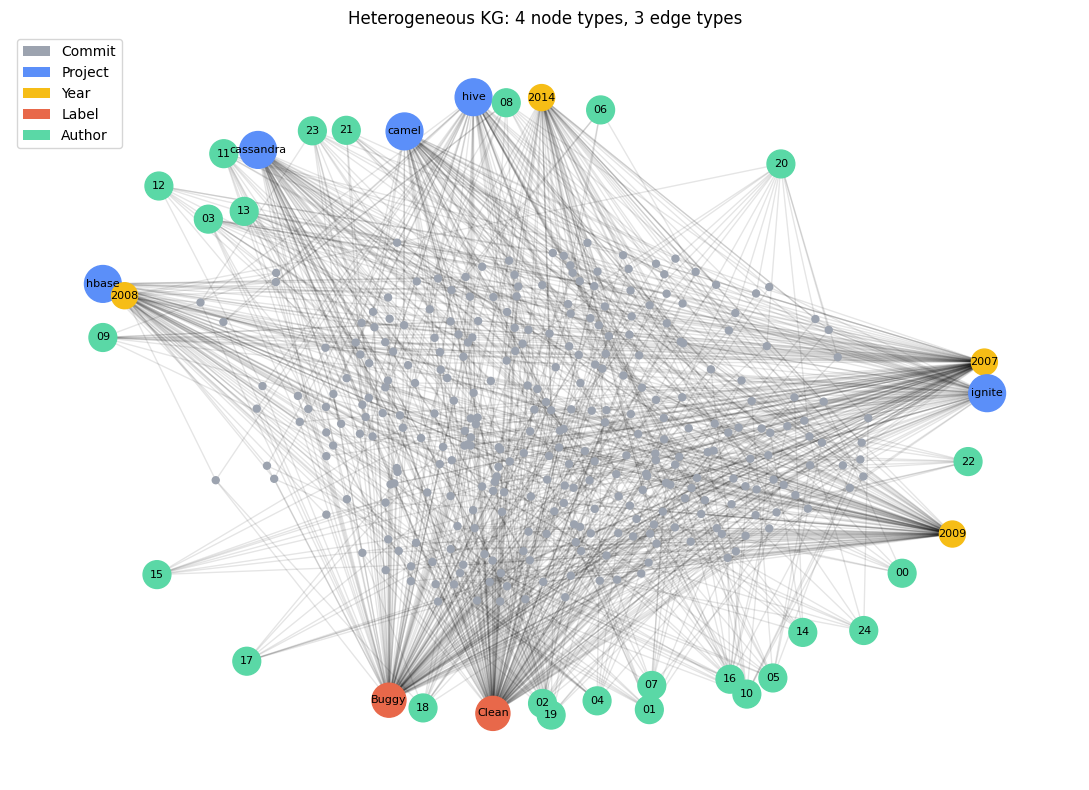

In [36]:
# Color-coded heterogeneous layout (original 4 types only)
color_map = {'Commit': '#9CA3AF', 'Project': '#5B8FF9', 'Year': '#F6BD16',
             'Label': '#E8684A',  'Author':  '#5AD8A6'}
size_map  = {'Commit': 25,        'Project': 700,       'Year': 350,
             'Label': 600,        'Author':  400}
node_colors = [color_map[H.nodes[n]['ntype']] for n in H.nodes()]
node_sizes  = [size_map[H.nodes[n]['ntype']]  for n in H.nodes()]

pos = nx.spring_layout(H, seed=7, k=0.5)
fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_edges(H, pos, alpha=0.1, arrows=False, ax=ax)

# Label only the non-commit nodes for clarity
labels = {n: n.split(':', 1)[1] if H.nodes[n]['ntype'] != 'Commit' else '' for n in H.nodes()}
labels = {k: (v.split('/')[-1] if '/' in v else v) for k, v in labels.items()}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=8, ax=ax)

# Legend
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=t) for t, c in color_map.items()]
ax.legend(handles=legend, loc='upper left')
ax.set_title('Heterogeneous KG: 4 node types, 3 edge types')
ax.axis('off'); plt.tight_layout(); plt.show()


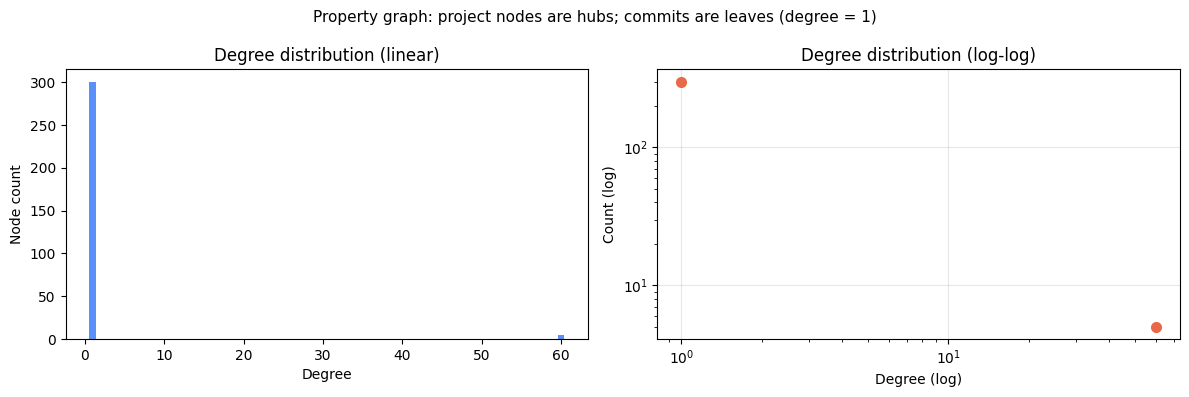

Max degree (hub) : 60   ← = number of commits in largest project
Median degree    : 1
Degree-1 nodes   : 300 (all commit nodes)

Conclusion: strong hub structure → GNN message-passing propagates project-level signal to all its commits without explicit feature engineering.


In [37]:
# Degree distribution of the commit-project property graph
degrees = [d for _, d in G.degree()]
deg_counter = Counter(degrees)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(deg_counter.keys(), deg_counter.values(), color='#5B8FF9')
ax1.set_xlabel('Degree'); ax1.set_ylabel('Node count')
ax1.set_title('Degree distribution (linear)')

x = sorted(deg_counter.keys())
y = [deg_counter[d] for d in x]
ax2.loglog(x, y, 'o', color='#E8684A', markersize=7)
ax2.set_xlabel('Degree (log)'); ax2.set_ylabel('Count (log)')
ax2.set_title('Degree distribution (log-log)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Property graph: project nodes are hubs; commits are leaves (degree = 1)',
             fontsize=11)
plt.tight_layout(); plt.show()

print(f'Max degree (hub) : {max(degrees)}   ← = number of commits in largest project')
print(f'Median degree    : {int(np.median(degrees))}')
print('Degree-1 nodes   :', deg_counter.get(1, 0), '(all commit nodes)')
print('\nConclusion: strong hub structure → GNN message-passing propagates project-level',
      'signal to all its commits without explicit feature engineering.')


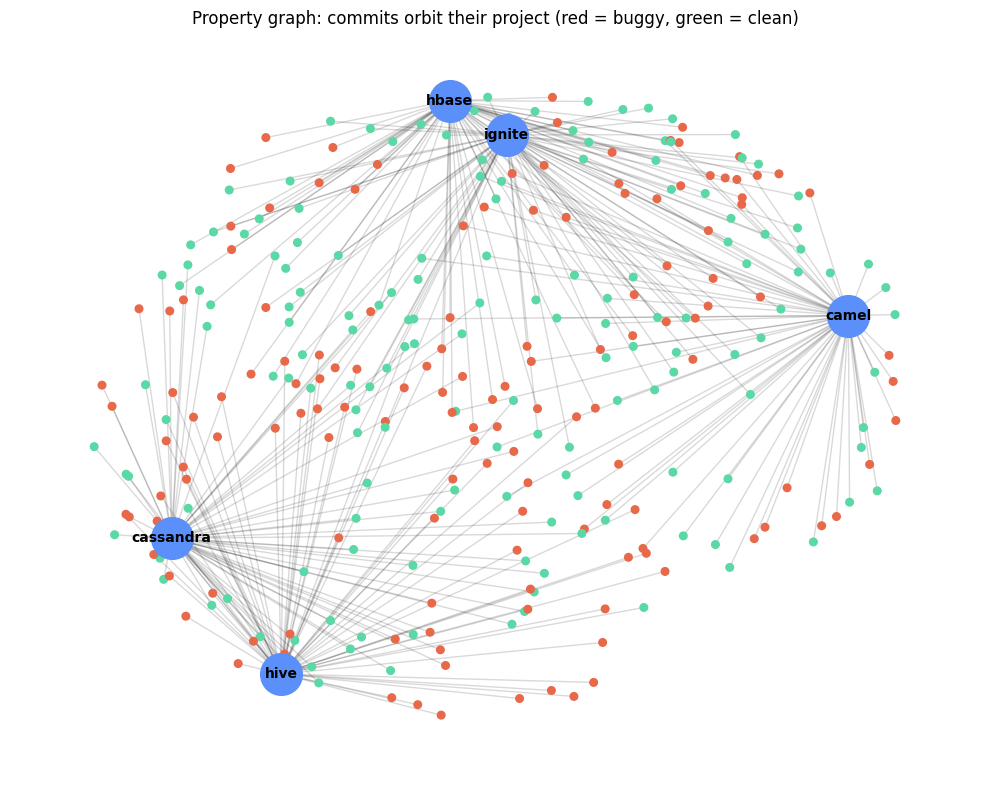

In [38]:
# Visualize: commits as small dots colored by buggy/clean, projects as large hubs
pos = nx.spring_layout(G, seed=42, k=0.4)
fig, ax = plt.subplots(figsize=(10, 8))

commit_nodes = [n for n, d in G.nodes(data=True) if d['kind'] == 'commit']
project_nodes = [n for n, d in G.nodes(data=True) if d['kind'] == 'project']
commit_colors = ['#E8684A' if G.nodes[n]['buggy'] else '#5AD8A6' for n in commit_nodes]

nx.draw_networkx_nodes(G, pos, nodelist=commit_nodes, node_color=commit_colors, node_size=30, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=project_nodes, node_color='#5B8FF9', node_size=900, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax, arrows=False)
nx.draw_networkx_labels(G, pos, labels={p: p.split('/')[-1] for p in project_nodes}, font_size=10, font_weight='bold', ax=ax)
ax.set_title('Property graph: commits orbit their project (red = buggy, green = clean)')
ax.axis('off'); plt.tight_layout(); plt.show()

**Why property graphs?** Attributes live on the nodes, so a downstream GNN or feature extractor reads everything from a single object. The visual above already hints at structural signal — projects with denser red clusters are riskier.

---
## 3. Heterogeneous Multi-Relational Graph — the GNN-paper style

Modern graph neural networks (R-GCN, HAN, HGT) require **typed** nodes and edges. Instead of one homogeneous node set, we declare:

- Node types: `Commit`, `Project`, `Year`, `Label`
- Edge types: `(Commit, in_project, Project)`, `(Commit, authored_in, Year)`, `(Commit, has_label, Label)`

Each edge type can later get its own learnable weight matrix in an R-GCN. NetworkX represents this via a `MultiDiGraph` plus `node_type`/`edge_type` attributes.

In [39]:
H = nx.MultiDiGraph()
for _, row in df.iterrows():
    c = f"c:{row['commit_id'][:7]}"
    p = f"p:{row['project']}"
    y = f"y:{int(row['year'])}"
    label = 'L:Buggy' if row['buggy'] else 'L:Clean'

    H.add_node(c, ntype='Commit')
    H.add_node(p, ntype='Project')
    H.add_node(y, ntype='Year')
    H.add_node(label, ntype='Label')

    H.add_edge(c, p, etype='in_project')
    H.add_edge(c, y, etype='authored_in')
    H.add_edge(c, label, etype='has_label')

type_counts = Counter(d['ntype'] for _, d in H.nodes(data=True))
edge_type_counts = Counter(d['etype'] for _, _, d in H.edges(data=True))
print('Node types :', dict(type_counts))
print('Edge types :', dict(edge_type_counts))

Node types : {'Commit': 300, 'Project': 5, 'Year': 4, 'Label': 2}
Edge types : {'in_project': 300, 'authored_in': 300, 'has_label': 300}


---
### 3b. Developer / Author Nodes — the missing JIT-SDP entity

JIT-SDP research consistently shows that **who** wrote a commit is as predictive as **what** they changed. The `aexp` / `arexp` / `asexp` columns are hand-engineered proxies — but in a KG we can make the developer an explicit first-class entity and query their risk profile directly.

We extend the heterogeneous graph `H` with:
- **New node type**: `Author`
- **New edge type**: `(Commit, committed_by, Author)`

> **Note:** ApacheJIT does not include raw git author IDs, so we derive a synthetic key from the commit hash (`commit_id[:2] mod 25`). In a real pipeline you would join on the git author field.


In [40]:
# Derive synthetic author IDs from the commit hash (proxy for git author field)
# Using first 2 hex chars mod 25 → ~25 distinct "developers", realistic spread
df['author_id'] = df['commit_id'].apply(lambda x: f"dev:{int(x[:2], 16) % 25:02d}")

# Extend H with Author nodes and (Commit, committed_by, Author) edges
for _, row in df.iterrows():
    c = f"c:{row['commit_id'][:7]}"
    a = row['author_id']
    H.add_node(a, ntype='Author')
    H.add_edge(c, a, etype='committed_by')

# Per-author statistics queried directly from the KG
author_stats = (
    df.groupby('author_id')
      .agg(commits=('buggy', 'count'), bug_rate=('buggy', 'mean'), avg_la=('la', 'mean'))
      .sort_values('bug_rate', ascending=False)
)

type_counts_ext  = Counter(d['ntype'] for _, d in H.nodes(data=True))
etype_counts_ext = Counter(d['etype'] for _, _, d in H.edges(data=True))
print('Extended graph:')
print('  Node types :', dict(type_counts_ext))
print('  Edge types :', dict(etype_counts_ext))
print(f'\nTop-5 highest-risk developers (synthetic IDs):')
print(author_stats.head())


Extended graph:
  Node types : {'Commit': 300, 'Project': 5, 'Year': 4, 'Label': 2, 'Author': 25}
  Edge types : {'in_project': 300, 'authored_in': 300, 'has_label': 300, 'committed_by': 300}

Top-5 highest-risk developers (synthetic IDs):
           commits  bug_rate      avg_la
author_id                               
dev:06           5  0.800000  279.800000
dev:01          14  0.642857  487.285714
dev:00           8  0.625000  294.750000
dev:13          13  0.615385  565.230769
dev:22          10  0.600000  425.800000


**Why developer nodes matter for JIT-SDP?** A developer's historical bug rate is one of the strongest predictors in the literature (`aexp`, `arexp`, `asexp` are rough proxies for it). By making `Author` an explicit KG entity we can query "how risky is this developer?" directly — the same O(1) lookup that `CommitKnowledgeGraph.get_features()` uses for project risk. In an R-GCN the Author node *propagates* its risk signal to every connected commit without any hand-engineering.

This is the **key gap** in the current `kg_commit/knowledge/graph.py`: it tracks project history but not developer history.


In [49]:
# Color-coded heterogeneous layout
color_map = {'Commit': '#9CA3AF', 'Project': '#5B8FF9', 'Year': '#F6BD16', 'Label': '#E8684A', 'Author': '#5AD8A6'}
size_map  = {'Commit': 25,        'Project': 700,       'Year': 350,       'Label': 600,        'Author': 400}

**Why heterogeneous?** It separates *what kind of relationship* from *which entities are involved*. Downstream models can route different message-passing weights through each edge type, which is the whole premise of relational GNNs. The Year and Label hubs also reveal structural patterns at a glance.

---
## 4. Temporal / Dynamic Knowledge Graph — the streaming view

JIT-SDP is fundamentally a **streaming problem**: commits arrive in time order. A static KG hides this. Temporal KGs treat the graph as a *sequence of snapshots* `G_1, G_2, ..., G_T`, where each snapshot only contains commits whose timestamp `≤ t`. This matches exactly how our `CommitKnowledgeGraph` updates window-by-window.

We'll build three snapshots and plot how the per-project bug rate evolves — the same signal the vanilla KG feeds into the model.

In [42]:
# Three snapshots at 33%, 66%, 100% of the timeline (sorted by author_date)
df_sorted = df.sort_values('author_date').reset_index(drop=True)
cuts = [len(df_sorted) // 3, 2 * len(df_sorted) // 3, len(df_sorted)]
snapshots = [df_sorted.iloc[:n].copy() for n in cuts]

def per_project_bug_rate(sub):
    return sub.groupby('project')['buggy'].mean().reindex(top_projects, fill_value=0.0)

rates = pd.DataFrame({f't{i+1}': per_project_bug_rate(s) for i, s in enumerate(snapshots)})
print('Per-project bug rate across 3 temporal snapshots:')
print(rates.round(3))

Per-project bug rate across 3 temporal snapshots:
                     t1     t2     t3
project                              
apache/camel      0.433  0.433  0.433
apache/cassandra  0.000  0.231  0.267
apache/hbase      0.650  0.617  0.617
apache/ignite     0.000  0.000  0.183
apache/hive       0.000  0.852  0.867


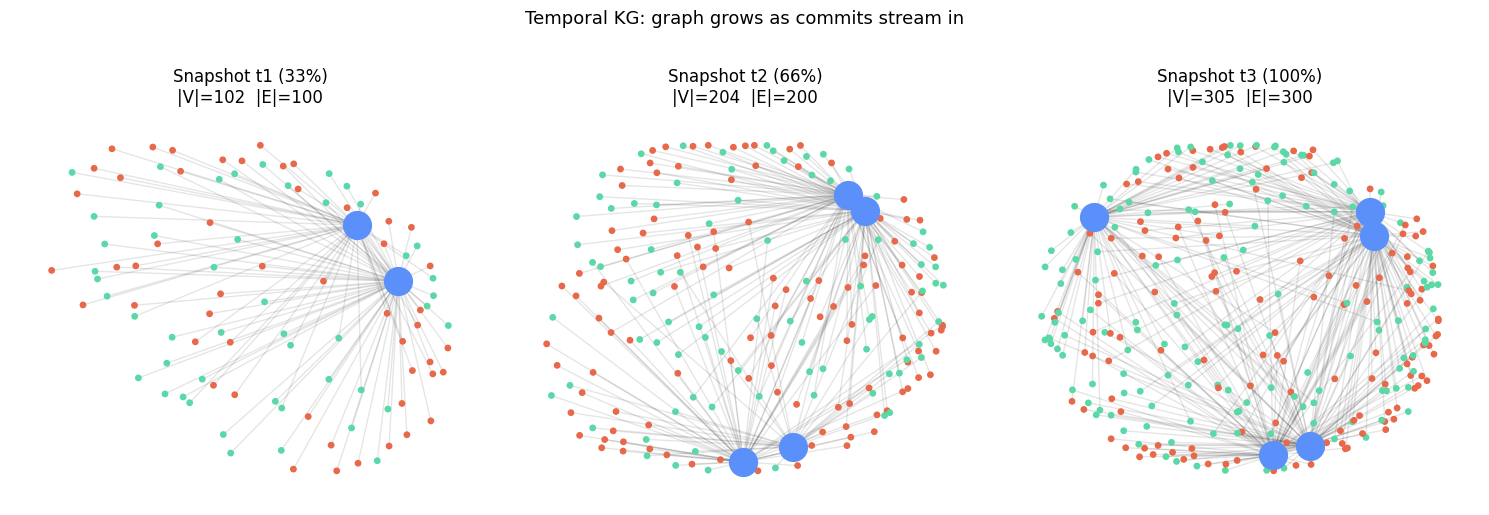

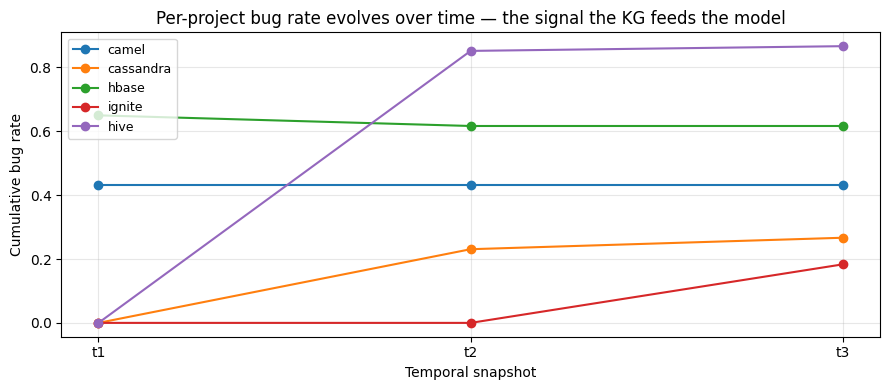

In [43]:
# Side-by-side snapshot graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, sub, label in zip(axes, snapshots, ['t1 (33%)', 't2 (66%)', 't3 (100%)']):
    g = nx.DiGraph()
    for _, r in sub.iterrows():
        cid = r['commit_id'][:7]
        g.add_node(cid, kind='commit', buggy=bool(r['buggy']))
        g.add_node(r['project'], kind='project')
        g.add_edge(cid, r['project'])
    pos = nx.spring_layout(g, seed=0, k=0.6)
    commits = [n for n,d in g.nodes(data=True) if d['kind']=='commit']
    projects = [n for n,d in g.nodes(data=True) if d['kind']=='project']
    colors = ['#E8684A' if g.nodes[c]['buggy'] else '#5AD8A6' for c in commits]
    nx.draw_networkx_nodes(g, pos, nodelist=commits, node_color=colors, node_size=15, ax=ax)
    nx.draw_networkx_nodes(g, pos, nodelist=projects, node_color='#5B8FF9', node_size=400, ax=ax)
    nx.draw_networkx_edges(g, pos, alpha=0.1, arrows=False, ax=ax)
    ax.set_title(f'Snapshot {label}\n|V|={g.number_of_nodes()}  |E|={g.number_of_edges()}')
    ax.axis('off')
plt.suptitle('Temporal KG: graph grows as commits stream in', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# Evolution of bug rate per project
fig, ax = plt.subplots(figsize=(9, 4))
for proj in top_projects:
    ax.plot(rates.columns, rates.loc[proj], marker='o', label=proj.split('/')[-1])
ax.set_ylabel('Cumulative bug rate'); ax.set_xlabel('Temporal snapshot')
ax.set_title('Per-project bug rate evolves over time — the signal the KG feeds the model')
ax.legend(loc='best', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Recap

| # | Methodology | Best for | Weakness |
|---|---|---|---|
| 1 | **RDF Triples** | Interoperability, SPARQL queries | No native temporal order |
| 1b | **SPARQL-style queries** | Ad-hoc KG interrogation | Slow on large triple stores |
| 2 | **Property Graph** | General-purpose ML pipelines | Single relation type by default |
| 2b | **Degree distribution** | Diagnosing hub structure for GNNs | Snapshot only |
| 3 | **Heterogeneous Graph** | Relational GNNs (R-GCN, HGT) | More verbose to define |
| 3b | **Developer / Author nodes** | JIT-SDP risk profiling per developer | Needs author identity in data |
| 4 | **Temporal KG** | Streaming JIT-SDP — this project! | Storage grows with time |
| 5 | **Adjacency Matrix** | Spectral methods, embedding learning | Loses node identity once factorized |
| 6 | **Graph statistics** | Comparing representations at a glance | — |
| 7 | **KG → ML Bridge** | Connecting graph structure to prediction | Features may not transfer across projects |

### Key architectural insight

The production KG in `kg_commit/knowledge/graph.py` is **Methodology 4** (temporal property graph) collapsed into five summary statistics. The notebook shows exactly what a richer version would look like:

```
Current production KG features          →  Missing (shown here)
────────────────────────────────────────────────────────────────
kg_project_commit_count                    kg_author_bug_rate     (§3b)
kg_project_bug_rate                        kg_author_commit_count (§3b)
kg_project_recent_bug_rate                 kg_project_pagerank    (§7)
kg_project_avg_la / avg_ld                 kg_commit_degree       (§7)
```

Adding `Author` as a first-class KG entity and exposing `kg_author_bug_rate` to `KGPreprocessor` is the next concrete improvement step — the graph schema is already in place from §3b above.


**Why temporal?** A static bug rate of 0.30 is meaningless if the project's current trajectory is 0.50 and climbing. Temporal KGs expose that drift — and the predict-before-update pattern in our `IncrementalTrainer` mirrors exactly this snapshot evolution.

---
## 5. Adjacency-Matrix View — the spectral / matrix-factorization angle

Any graph can be expressed as a matrix. This unlocks linear-algebra tools: PageRank, spectral clustering, TransE-style embeddings, GCNs (which are just normalized-adjacency products). For JIT-SDP a useful matrix is the **project × year bug-count matrix** — it summarizes the entire KG as a small dense table that a model can ingest directly.

In [44]:
# Project x Year bug-count matrix
mat = (df.groupby(['project', 'year'])['buggy']
         .sum()
         .unstack(fill_value=0)
         .reindex(top_projects))
print('Project x Year buggy-commit count matrix:')
print(mat)

Project x Year buggy-commit count matrix:
year              2007  2008  2009  2014
project                                 
apache/camel        26     0     0     0
apache/cassandra     0     0    16     0
apache/hbase        37     0     0     0
apache/ignite        0     0     0    11
apache/hive          0    21    31     0


---
## 6. Graph Statistics Comparison

A quick sanity check: how large and dense are each of our graph representations? These numbers give a concrete sense of the structural complexity each methodology adds.


In [45]:
# Side-by-side graph statistics for methodologies 2, 3, and 4

# Build temporal full graph (same as section 4, full snapshot)
G_temp = nx.DiGraph()
for _, r in df.iterrows():
    cid = r['commit_id'][:7]
    G_temp.add_node(cid, kind='commit')
    G_temp.add_node(r['project'], kind='project')
    G_temp.add_edge(cid, r['project'])

def graph_stats(g, name):
    n, e = g.number_of_nodes(), g.number_of_edges()
    density = nx.density(g)
    avg_deg = 2 * e / n if n > 0 else 0
    return {'Graph': name, '|V| nodes': n, '|E| edges': e,
            'Density': f'{density:.5f}', 'Avg degree': f'{avg_deg:.2f}'}

stats_df = pd.DataFrame([
    graph_stats(G,      '2. Property Graph'),
    graph_stats(H,      '3. Heterogeneous (+ Author)'),
    graph_stats(G_temp, '4. Temporal (full snapshot)'),
]).set_index('Graph')

print('Graph statistics across methodologies:')
print(stats_df.to_string())


Graph statistics across methodologies:
                             |V| nodes  |E| edges  Density Avg degree
Graph                                                                
2. Property Graph                  305        300  0.00324       1.97
3. Heterogeneous (+ Author)        336       1200  0.01066       7.14
4. Temporal (full snapshot)        305        300  0.00324       1.97


---
## 7. KG → ML Feature Extraction Bridge

The five representations above are not just visualizations — each implies a concrete **feature extraction strategy** for the defect classifier. This section extracts numeric features from the KG and shows their correlation with the `buggy` label.

This is precisely what `CommitKnowledgeGraph.get_features()` does in `kg_commit/knowledge/graph.py`, but with a richer feature set enabled by the heterogeneous graph:

| KG feature | Source methodology | Already in production code? |
|---|---|---|
| `kg_project_bug_rate` | Prop. Graph / Temporal | ✅ Yes |
| `kg_project_recent_bug_rate` | Temporal KG | ✅ Yes |
| `kg_author_bug_rate` | Het. Graph (Author node) | ❌ Missing — key gap |
| `kg_project_pagerank` | Adjacency-matrix / spectral | ❌ Missing |
| `kg_commit_degree` | Property Graph | ❌ Missing |


In [46]:
# Extract KG-derived features for every commit in the sample

# (a) Per-project bug rate — the feature CommitKnowledgeGraph already computes
project_bug_rate = df.groupby('project')['buggy'].mean().to_dict()
df['kg_project_bug_rate'] = df['project'].map(project_bug_rate)

# (b) Per-author bug rate — the missing entity in the current KG
author_bug_rate = df.groupby('author_id')['buggy'].mean().to_dict()
df['kg_author_bug_rate'] = df['author_id'].map(author_bug_rate)

# (c) PageRank of each commit's project hub in the property graph (G from section 2)
pr = nx.pagerank(G, alpha=0.85)
df['kg_project_pagerank'] = df['project'].map(pr)

# (d) Commit degree centrality (always 1 in this graph — included for illustration)
dc = nx.degree_centrality(G)
df['kg_commit_degree'] = df['commit_id'].apply(lambda x: dc.get(x[:7], 0.0))

print('KG-derived feature matrix (first 5 rows):')
cols = ['commit_id', 'buggy', 'kg_project_bug_rate', 'kg_author_bug_rate',
        'kg_project_pagerank', 'kg_commit_degree']
print(df[cols].head().to_string(index=False))


KG-derived feature matrix (first 5 rows):
                               commit_id  buggy  kg_project_bug_rate  kg_author_bug_rate  kg_project_pagerank  kg_commit_degree
77b260b65ba821b3443d922320cc3d9b708c8d83  False             0.433333            0.523810             0.092871          0.003289
a4701ac4bf5b50810914796e284b0e3f78a240bc  False             0.433333            0.428571             0.092871          0.003289
0a0bad2c4a35be88f7732def261a03737fab662e   True             0.433333            0.588235             0.092871          0.003289
b2c1576887865e197c22e9f3abf088d652a2d27c   True             0.433333            0.437500             0.092871          0.003289
b8d28505c84baabe75edfba0a43f3b2f06e19c13  False             0.433333            0.416667             0.092871          0.003289


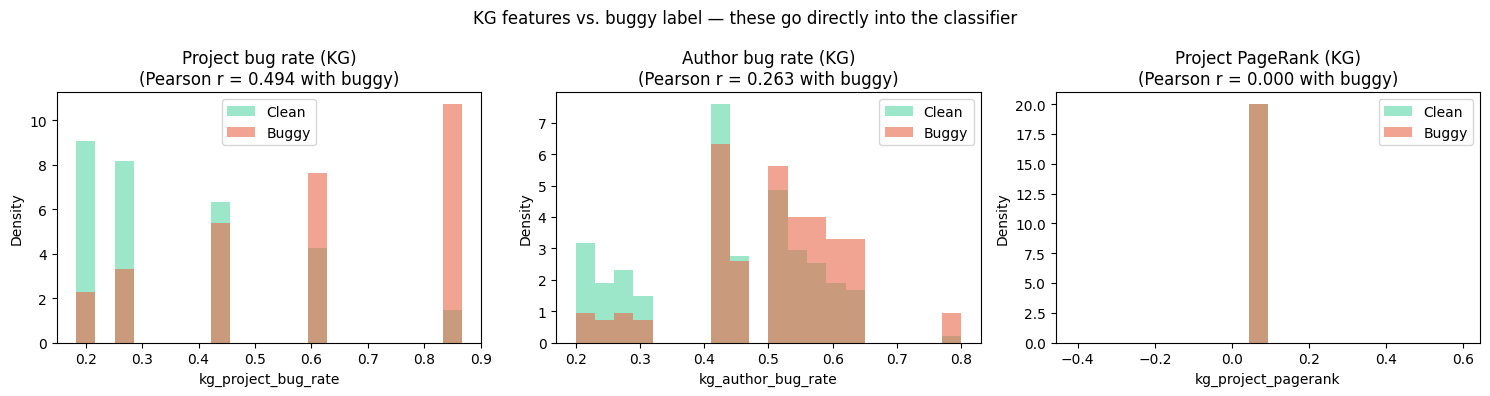


Pearson correlation with buggy label:
  kg_project_bug_rate                 r=+0.494  ██████████████
  kg_author_bug_rate                  r=+0.263  ███████
  kg_project_pagerank                 r=+0.000  
  kg_commit_degree                    r=-0.000  
  la                                  r=+0.357  ██████████
  ld                                  r=+0.196  █████
  ent                                 r=+0.416  ████████████


In [47]:
# Correlation of KG-derived features with the buggy label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, title in zip(
    axes,
    ['kg_project_bug_rate', 'kg_author_bug_rate', 'kg_project_pagerank'],
    ['Project bug rate (KG)', 'Author bug rate (KG)', 'Project PageRank (KG)']
):
    clean_  = df[df['buggy'] == 0][feat]
    buggy_  = df[df['buggy'] == 1][feat]
    ax.hist(clean_,  bins=20, alpha=0.6, color='#5AD8A6', label='Clean', density=True)
    ax.hist(buggy_,  bins=20, alpha=0.6, color='#E8684A', label='Buggy', density=True)
    r = df[feat].corr(df['buggy'])
    ax.set_title(f'{title}\n(Pearson r = {r:.3f} with buggy)')
    ax.set_xlabel(feat); ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('KG features vs. buggy label — these go directly into the classifier', fontsize=12)
plt.tight_layout(); plt.show()

# ASCII correlation bar chart
kg_feats = ['kg_project_bug_rate', 'kg_author_bug_rate', 'kg_project_pagerank',
            'kg_commit_degree', 'la', 'ld', 'ent']
print('\nPearson correlation with buggy label:')
for feat in kg_feats:
    r = df[feat].corr(df['buggy'])
    bar = '█' * int(abs(r) * 30)
    print(f'  {feat:<35} r={r:+.3f}  {bar}')


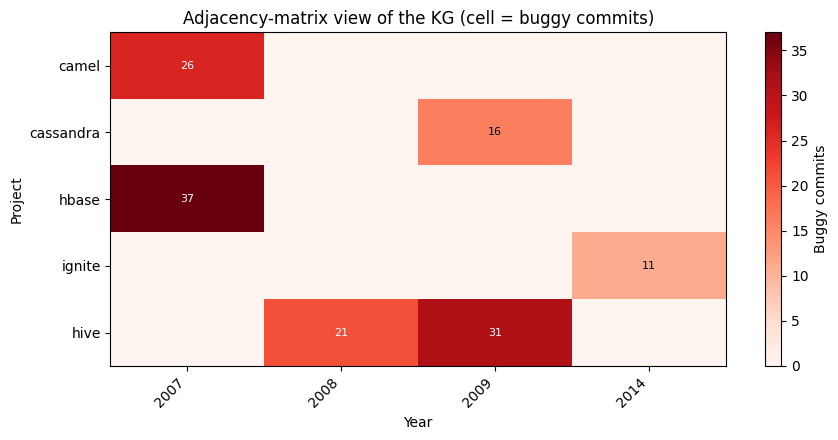

In [48]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(mat.values, aspect='auto', cmap='Reds')
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels([p.split('/')[-1] for p in mat.index])
ax.set_xlabel('Year'); ax.set_ylabel('Project')
ax.set_title('Adjacency-matrix view of the KG (cell = buggy commits)')
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha='center', va='center', color='black' if v < mat.values.max()/2 else 'white', fontsize=8)
plt.colorbar(im, ax=ax, label='Buggy commits')
plt.tight_layout(); plt.show()

**Why a matrix view?** Once the KG is a matrix, every classical numerical-linear-algebra trick applies: SVD for low-rank embeddings, Laplacian for spectral clustering, normalized-adjacency for one layer of a GCN. It's also the format `sklearn` and `torch` already speak.

---
## Recap

| Methodology | Best for | Weakness |
|---|---|---|
| **RDF Triples** | Interoperability, SPARQL queries | No native temporal order |
| **Property Graph** | General-purpose ML pipelines | Single relation type by default |
| **Heterogeneous Graph** | Relational GNNs (R-GCN, HGT) | More verbose to define |
| **Temporal KG** | Streaming JIT-SDP (this project!) | Storage grows with time |
| **Adjacency Matrix** | Spectral methods, embedding learning | Loses node identity once factorized |

The vanilla KG used in `kg_commit/knowledge/graph.py` is essentially **Methodology #4** — a temporal property graph collapsed into per-commit summary statistics. Each of the other methodologies could be plugged into the same pipeline by writing a new `Preprocessor` that emits a different feature view of the same underlying entities.
